In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Serif'  # 논문용 폰트
plt.rcParams['font.size'] = '11'  # 논문용 폰트

def visualization_long_dependencies(
    PatchTST_mse, PatchTST_mae,
    SpikF_mse, SpikF_mae,
    Spikformer_mse, Spikformer_mae,
    SMformer_mse, SMformer_mae,
):
    # pred_len 리스트
    pred_lens = np.array([96, 192, 336, 720], dtype=float)
    pred_lens_idx = np.array([0, 1, 2, 3])

    # 길이 체크
    assert len(pred_lens) == len(PatchTST_mse) == len(PatchTST_mae)
    assert len(pred_lens) == len(Spikformer_mse) == len(Spikformer_mae)
    assert len(pred_lens) == len(SpikF_mse) == len(SpikF_mae)
    assert len(pred_lens) == len(SMformer_mse) == len(SMformer_mae)

    PatchTST_mse = np.array(PatchTST_mse)
    PatchTST_mae = np.array(PatchTST_mae)
    Spikformer_mse = np.array(Spikformer_mse)
    Spikformer_mae = np.array(Spikformer_mae)
    SMformer_mse = np.array(SMformer_mse)
    SMformer_mae = np.array(SMformer_mae)
    SpikF_mse = np.array(SpikF_mse)
    SpikF_mae = np.array(SpikF_mae)

    # -----------------------------------
    # 1) PatchTST 대비 개선율(%) 계산
    #    (PatchTST - 모델) / PatchTST * 100
    # -----------------------------------
    spk_imp_mse = (PatchTST_mse - Spikformer_mse) / PatchTST_mse * 100.0
    smf_imp_mse = (PatchTST_mse - SMformer_mse)   / PatchTST_mse * 100.0
    spF_imp_mse = (PatchTST_mse - SpikF_mse)   / PatchTST_mse * 100.0

    spk_imp_mae = (PatchTST_mae - Spikformer_mae) / PatchTST_mae * 100.0
    smf_imp_mae = (PatchTST_mae - SMformer_mae)   / PatchTST_mae * 100.0
    spF_imp_mae = (PatchTST_mae - SpikF_mae)   / PatchTST_mae * 100.0

    # -----------------------------------
    # 2) Figure / Subplot 설정
    # -----------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=150)
    ax_mse, ax_mae = axes

    # -----------------------------------
    # 3) MSE 기준 long dependency 개선율
    # -----------------------------------
    # PatchTST = 0% baseline
    ax_mse.axhline(0.0, linestyle=':', linewidth=1.0)

    ax_mse.plot(
        pred_lens_idx, spk_imp_mse,
        marker='s', linestyle='--', linewidth=1.8,
        label='Spikformer'
    )
    ax_mse.plot(
        pred_lens_idx, spF_imp_mse,
        marker='^', linestyle='-.', linewidth=1.8,
        label='SpikF'
    )
    ax_mse.plot(
        pred_lens_idx, smf_imp_mse,
        marker='^', linestyle='-.', linewidth=1.8,
        label='Ours'
    )

    ax_mse.set_xlabel('prediction length')
    ax_mse.set_ylabel('Improvement over PatchTST (%)')
    ax_mse.set_title('MSE')
    ax_mse.grid(True, linestyle=':', alpha=0.5)
    ax_mse.legend()
    ax_mse.set_xticks(pred_lens_idx)
    ax_mse.set_xticklabels(pred_lens.astype(int))

    # -----------------------------------
    # 4) MAE 기준 long dependency 개선율
    # -----------------------------------
    ax_mae.axhline(0.0, linestyle=':', linewidth=1.0)

    ax_mae.plot(
        pred_lens_idx, spk_imp_mae,
        marker='s', linestyle='--', linewidth=1.8,
        label='Spikformer'
    )
    ax_mae.plot(
        pred_lens_idx, spF_imp_mae,
        marker='^', linestyle='-.', linewidth=1.8,
        label='SpikF'
    )

    ax_mae.plot(
        pred_lens_idx, smf_imp_mae,
        marker='^', linestyle='-.', linewidth=1.8,
        label='Ours'
    )

    ax_mae.set_xlabel('prediction length')
    ax_mae.set_ylabel('Improvement over PatchTST (%)')
    ax_mae.set_title('MAE')
    ax_mae.grid(True, linestyle=':', alpha=0.5)
    ax_mae.legend()
    ax_mae.set_xticks(pred_lens_idx)
    ax_mae.set_xticklabels(pred_lens.astype(int))

    plt.tight_layout()
    plt.savefig('long_dependencies_improvement.png', dpi=600)
    # plt.show()


# ETTm2

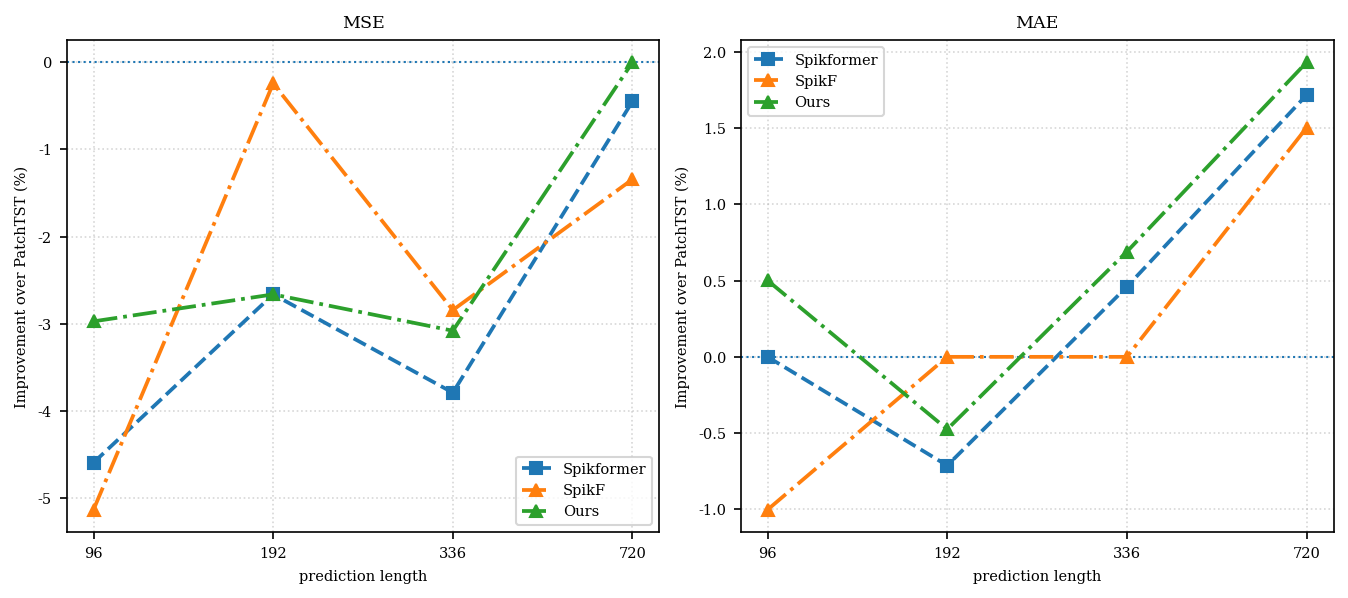

In [48]:
PatchTST_mse = [0.370 
,0.413 
,0.422 
,0.447 
]
PatchTST_mae = [0.399 
,0.421 
,0.435 
,0.466 
]

SpikF_mse = [
0.389 
,0.414 
,0.434 
,0.453 
]
SpikF_mae = [
0.403 
,0.421 
,0.435 
,0.459 
]

Spikformer_mse = [0.387 
,0.424 
,0.438 
,0.449 
]
Spikformer_mae = [0.399 
,0.424 
,0.433 
,0.458 
]

SMformer_mse = [0.381 
,0.424 
,0.435 
,0.447 

]
SMformer_mae = [0.397 
,0.423 
,0.432 
,0.457 

]

visualization_long_dependencies(PatchTST_mse, PatchTST_mae, SpikF_mse, SpikF_mae, Spikformer_mse, Spikformer_mae, SMformer_mse, SMformer_mae)

In [ ]:
PatchTST_mse = [0.165, 0.220, 0.274, 0.362]
PatchTST_mae = [0.255, 0.292, 0.329, 0.385]

Spikformer_mse = [0.169, 0.328, 0.359, 0.419]
Spikformer_mae = [0.256, 0.368, 0.389, 0.423]

SMformer_mse = [0.359, 0.328, 0.359, 0.418]
SMformer_mae = [0.381, 0.367, 0.388, 0.422]

/tmp/ipykernel_4002292/649038592.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Pastel1')


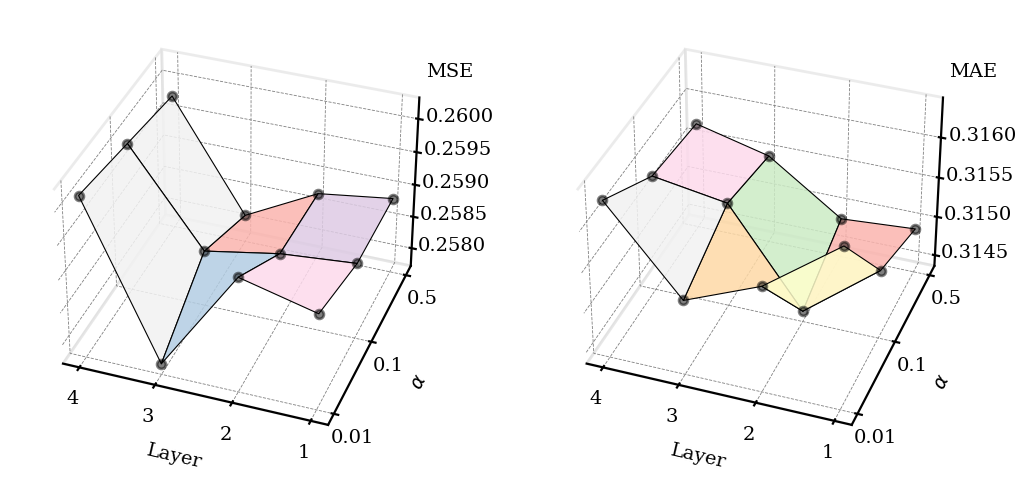

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.ticker import FormatStrFormatter

# -------------------------
# 1. 데이터 정의
# -------------------------
layers = np.array([4, 3, 2, 1])          # x축: layer 개수
keep_ratios = np.array([0.01, 0.1, 0.5])      # y축: alpha 값
alpha_idx = np.arange(len(keep_ratios))       # α축을 등간격으로 쓰기 위한 인덱스

X, Y = np.meshgrid(layers, alpha_idx)

# 왼쪽: MSE, 오른쪽: MAE
Z_mse = np.array([
    [0.26015075, 0.25788,   0.25945175, 0.25917275],
    [0.25996625, 0.2585705, 0.25877625, 0.25887575],
    [0.25978,    0.25813675,0.2587185,  0.448911]
])

Z_mae = np.array([
    [0.31629475, 0.3152905,   0.3156715, 0.316352],
    [0.31580325, 0.31565875, 0.31449375, 0.3152205],
    [0.3157,    0.3154735, 0.314854,  0.3149195]
])

# 두 플롯의 z축 범위를 통일
# z_min = min(Z_mse.min(), Z_mae.min())
# z_max = max(Z_mse.max(), Z_mae.max())

# -------------------------
# 2. 스타일 설정
# -------------------------
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 7

fig = plt.figure(figsize=(5, 2.4), dpi=200)
cmap = mpl.cm.get_cmap('Pastel1')
zfmt = FormatStrFormatter('%.4f')

def plot_panel(ax, Z, title):
    # surface
    ax.plot_surface(
        X, Y, Z,
        cmap=cmap,
        edgecolor='k',
        linewidth=0.4,
        antialiased=True,
        alpha=0.85
    )

    # 꼭짓점 점 (회색 테두리 없애기 위해 depthshade=False)
    ax.scatter(
        X, Y, Z,
        c='k',
        s=10,
        depthshade=False,
        alpha=0.5
    )

    # 축/눈금
    ax.set_xlabel("Layer", labelpad=-6)
    ax.set_ylabel(r"$\alpha$", labelpad=-6)
    ax.set_zlabel("")

    ax.set_xticks(layers)
    ax.set_yticks(alpha_idx)
    ax.set_yticklabels([str(a) for a in keep_ratios])

    ax.tick_params(axis='x', pad=-2.5, labelsize=7)
    ax.tick_params(axis='y', pad=-2.5, labelsize=7)
    ax.tick_params(axis='z', pad=2, labelsize=7)

    # x축 뒤집기 (원래 코드 유지)
    ax.invert_xaxis()

    # z축 범위/표기
    # ax.set_zlim(z_min, z_max)
    ax.zaxis.set_major_formatter(zfmt)

    # 배경/그리드 정리
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis.pane.set_edgecolor('0.85')
        axis._axinfo["grid"].update({
                                        "color": "gray",
                                        "linestyle": "--",
                                        "linewidth": 0.3,  # 너무 얇으면 안 보일 수 있으니 0.5 추천
                                        "alpha": 0.3,
                                    })
   
    # 보기 각도 & 제목
    ax.view_init(elev=35, azim=-70)
    # ax.set_title(title, pad=6, fontsize=8)
    ax.text2D(
        1.05, 0.9, title,
        transform=ax.transAxes,
        ha="right", va="top", fontsize=7
    )

# -------------------------
# 3. 두 개의 패널 그리기
# -------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_panel(ax1, Z_mse, "MSE")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_panel(ax2, Z_mae, "MAE")

plt.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.92, wspace=0.2)
plt.show()


/tmp/ipykernel_3722609/425797833.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Pastel1')


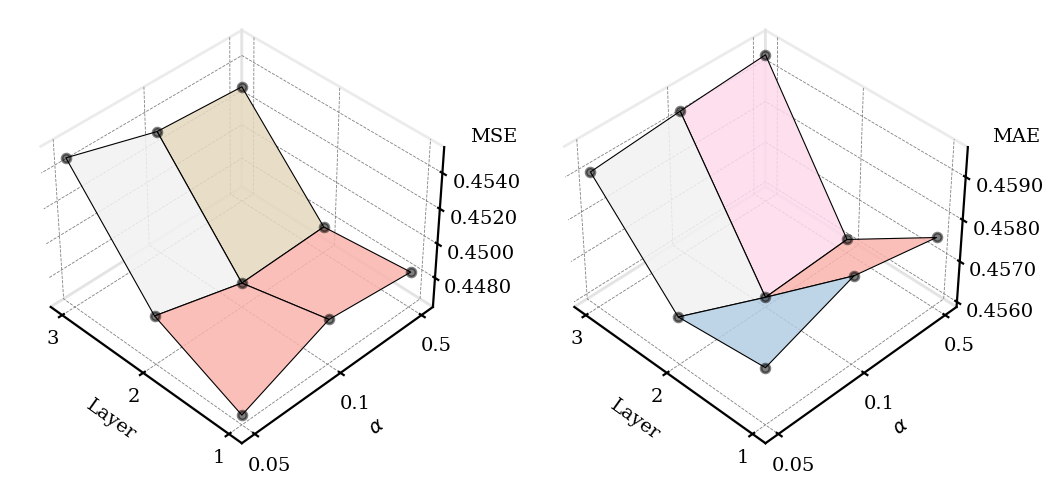

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.ticker import FormatStrFormatter

# -------------------------
# 1. 데이터 정의
# -------------------------
layers = np.array([3, 2, 1])          # x축: layer 개수
keep_ratios = np.array([0.05, 0.1, 0.5])      # y축: alpha 값
alpha_idx = np.arange(len(keep_ratios))       # α축을 등간격으로 쓰기 위한 인덱스

X, Y = np.meshgrid(layers, alpha_idx)

# 왼쪽: MSE, 오른쪽: MAE
# ETTh1 dataset
Z_mse = np.array([
    [0.454829,   0.449115, 0.446838], #0.05 0.447944, 
    [0.453349, 0.447692, 0.448911], #0.1 0.449628, 
    [0.453031,0.447817,  0.448343] #0.5 
])

Z_mae = np.array([
    [ 0.459116, 0.457037, 0.457267], #0.455303,
    [ 0.459293, 0.456114, 0.458018], # 0.455085,
    [ 0.459438, 0.456207,  0.457581] # 0.454726,
])

# 두 플롯의 z축 범위를 통일
# z_min = min(Z_mse.min(), Z_mae.min())
# z_max = max(Z_mse.max(), Z_mae.max())

# -------------------------
# 2. 스타일 설정
# -------------------------
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 7

fig = plt.figure(figsize=(5, 2.4), dpi=200)
cmap = mpl.cm.get_cmap('Pastel1')
zfmt = FormatStrFormatter('%.4f')

def plot_panel(ax, Z, title):
    # surface
    ax.plot_surface(
        X, Y, Z,
        cmap=cmap,
        edgecolor='k',
        linewidth=0.4,
        antialiased=True,
        alpha=0.85
    )

    # 꼭짓점 점 (회색 테두리 없애기 위해 depthshade=False)
    ax.scatter(
        X, Y, Z,
        c='k',
        s=10,
        depthshade=False,
        alpha=0.5
    )

    # 축/눈금
    ax.set_xlabel("Layer", labelpad=-8)
    ax.set_ylabel(r"$\alpha$", labelpad=-6)
    ax.set_zlabel("")

    ax.set_xticks(layers)
    ax.set_yticks(alpha_idx)
    ax.set_yticklabels([str(a) for a in keep_ratios])

    ax.tick_params(axis='x', pad=-4, labelsize=7)
    ax.tick_params(axis='y', pad=-2, labelsize=7)
    ax.tick_params(axis='z', pad=1, labelsize=7)

    # x축 뒤집기 (원래 코드 유지)
    ax.invert_xaxis()

    # z축 범위/표기
    # ax.set_zlim(z_min, z_max)
    ax.zaxis.set_major_formatter(zfmt)

    # 배경/그리드 정리
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis.pane.set_edgecolor('0.85')
        axis._axinfo["grid"].update({
                                        "color": "gray",
                                        "linestyle": "--",
                                        "linewidth": 0.3,  # 너무 얇으면 안 보일 수 있으니 0.5 추천
                                        "alpha": 0.3,
                                    })
   
    # 보기 각도 & 제목
    ax.view_init(elev=40, azim=-45)
    # ax.set_title(title, pad=6, fontsize=8)
    ax.text2D(
        1.15, 0.75, title,
        transform=ax.transAxes,
        ha="right", va="top", fontsize=7
    )

# -------------------------
# 3. 두 개의 패널 그리기
# -------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_panel(ax1, Z_mse, "MSE")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_panel(ax2, Z_mae, "MAE")

plt.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.92, wspace=0.2)
plt.show()


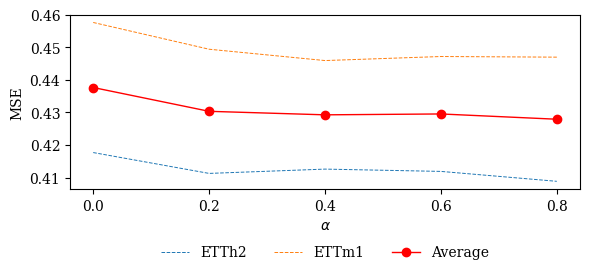

In [34]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Serif'
def plot_alpha_sensitivity_avg_mse_pred720(
    results,
    alphas=(0.0, 0.2, 0.4, 0.6, 0.8),
    datasets=("ETTh2", "ETTm1"),
    pred_len=720,
    out_path="alpha_sensitivity_avg_ETTh2_ETTm1_pred720.pdf",
    show_individual=False
):
    """
    Plot a single curve of averaged MSE across datasets for pred_len=720.

    results format:
        results[dataset][pred_len][alpha] = mse_value
    """
    alphas = [float(a) for a in alphas]

    # Collect per-dataset curves
    curves = {}
    for ds in datasets:
        y = []
        for a in alphas:
            v = np.nan
            if ds in results and pred_len in results[ds]:
                if a in results[ds][pred_len]:
                    v = results[ds][pred_len][a]
                else:
                    a_str = str(a)
                    if a_str in results[ds][pred_len]:
                        v = results[ds][pred_len][a_str]
            y.append(v)
        curves[ds] = np.array(y, dtype=float)

    # Average across datasets (nanmean so it won't crash if one value missing)
    Y = np.vstack([curves[ds] for ds in datasets])
    y_avg = np.nanmean(Y, axis=0)

    fig = plt.figure(figsize=(6, 3))
    if show_individual:
        for ds in datasets:
            plt.plot(alphas, curves[ds], linestyle="--", label=f"{ds}", linewidth=0.7)

    plt.plot(alphas, y_avg, marker="o", label=f"Average", linewidth=1, c='r')

    # Optional: show individual dataset curves lightly (helps reviewers, still simple)
    
    plt.xlabel(r"$\alpha$")
    plt.ylabel("MSE")
    # plt.title(r"$\alpha$"+f" Sensitivity (MSE, pred_len={pred_len})")
    plt.xticks(alphas)
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.25),  # 아래로 내림 (값은 필요하면 -0.12 ~ -0.25 사이로 조절)
        ncol=3,                       # 항목 개수에 맞게 (avg만이면 1, avg+2개면 3)
        frameon=False
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=1200)
    plt.show()
# =========================
# Example usage (fill your MSE values)
# =========================
results = {
    "ETTh2": {
        720: {0.0: 0.417658, 0.2: 0.411258, 0.4: 0.412579, 0.6: 0.411874, 0.8: 0.408831},
    },
    "ETTm1": {
        720: {0.0: 0.457572, 0.2: 0.449362, 0.4: 0.445885, 0.6: 0.447126, 0.8: 0.446931},
    },
}

plot_alpha_sensitivity_avg_mse_pred720(results, show_individual=True)

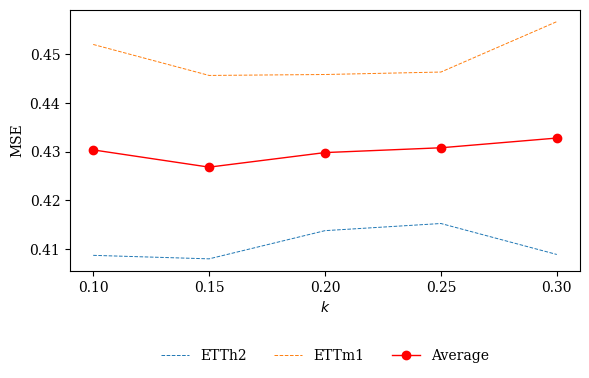

In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Serif'
def plot_k_sensitivity_avg_mse_pred720(
    results,
    keep_ratios=(0.1, 0.15, 0.2, 0.25, 0.3),
    datasets=("ETTh2", "ETTm1"),
    pred_len=720,
    out_path="k_sensitivity_avg_ETTh2_ETTm1_pred720.pdf",
    show_individual=False
):
    """
    Plot a single curve of averaged MSE across datasets for pred_len=720.

    results format:
        results[dataset][pred_len][alpha] = mse_value
    """
    keep_ratios = [float(k) for k in keep_ratios]

    # Collect per-dataset curves
    curves = {}
    for ds in datasets:
        y = []
        for a in keep_ratios:
            v = np.nan
            if ds in results and pred_len in results[ds]:
                if a in results[ds][pred_len]:
                    v = results[ds][pred_len][a]
                else:
                    a_str = str(a)
                    if a_str in results[ds][pred_len]:
                        v = results[ds][pred_len][a_str]
            y.append(v)
        curves[ds] = np.array(y, dtype=float)

    # Average across datasets (nanmean so it won't crash if one value missing)
    Y = np.vstack([curves[ds] for ds in datasets])
    y_avg = np.nanmean(Y, axis=0)

    fig = plt.figure(figsize=(6, 4))
    if show_individual:
        for ds in datasets:
            plt.plot(keep_ratios, curves[ds], linestyle="--", label=f"{ds}", linewidth=0.7)

    plt.plot(keep_ratios, y_avg, marker="o", label=f"Average", linewidth=1, c='r')

    # Optional: show individual dataset curves lightly (helps reviewers, still simple)
    
    plt.xlabel(r"$k$")
    plt.ylabel("MSE")
    # plt.title(r"$\alpha$"+f" Sensitivity (MSE, pred_len={pred_len})")
    plt.xticks(keep_ratios)
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.25),  # 아래로 내림 (값은 필요하면 -0.12 ~ -0.25 사이로 조절)
        ncol=3,                       # 항목 개수에 맞게 (avg만이면 1, avg+2개면 3)
        frameon=False
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=1200)
    plt.show()
# =========================
# Example usage (fill your MSE values)
# =========================
results = {
    "ETTh2": {
        720: {0.1: 0.408653, 0.15: 0.407932, 0.2: 0.413730, 0.25: 0.415199, 0.3: 0.408831},
    },
    "ETTm1": {
        720: {0.1: 0.452014, 0.15: 0.445644, 0.2: 0.445836, 0.25: 0.446342, 0.3: 0.456709},
    },
}

plot_k_sensitivity_avg_mse_pred720(results, show_individual=True)

   k  ETTh2_MSE  ETTm1_MSE  MITBIH_Acc  SMD_F1
0.10   0.408653   0.452014      0.9840  0.8619
0.15   0.407932   0.445644      0.9845  0.8694
0.20   0.413730   0.445836      0.9837  0.8605
0.25   0.415199   0.446342      0.9843  0.8638
0.30   0.408831   0.456709      0.9838  0.8773


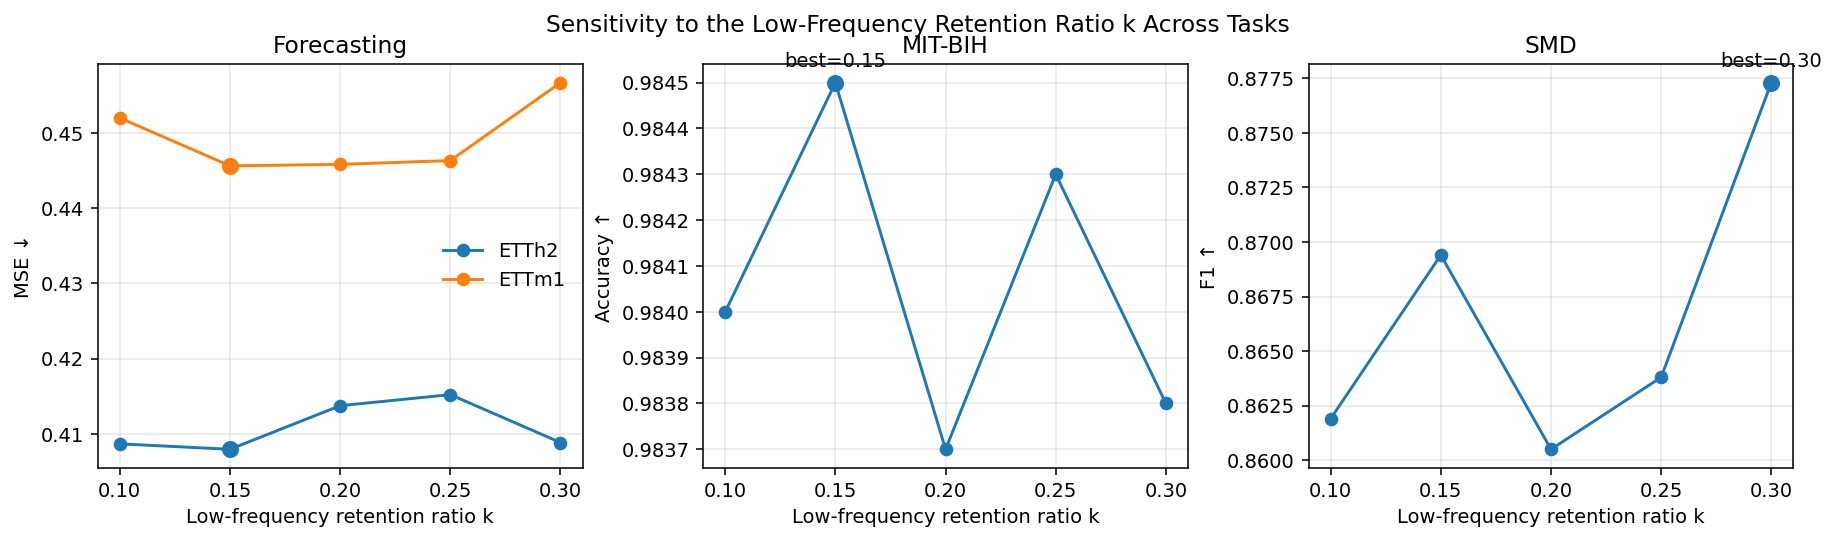

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# k: low-frequency retention ratio
k = np.array([0.10, 0.15, 0.20, 0.25, 0.30])

# Forecasting (lower is better)
etth2 = np.array([0.408653, 0.407932, 0.413730, 0.415199, 0.408831])
ettm1 = np.array([0.452014, 0.445644, 0.445836, 0.446342, 0.456709])

# Classification / anomaly detection (higher is better)
mitbih = np.array([0.9840, 0.9845, 0.9837, 0.9843, 0.9838])
smd = np.array([0.8619, 0.8694, 0.8605, 0.8638, 0.8773])

# Optional summary table
summary = pd.DataFrame({
    "k": k,
    "ETTh2_MSE": etth2,
    "ETTm1_MSE": ettm1,
    "MITBIH_Acc": mitbih,
    "SMD_F1": smd,
})
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)

# 1) Forecasting
axes[0].plot(k, etth2, marker='o', label='ETTh2')
axes[0].plot(k, ettm1, marker='o', label='ETTm1')
axes[0].set_title('Forecasting')
axes[0].set_xlabel('Low-frequency retention ratio k')
axes[0].set_ylabel('MSE ↓')
axes[0].set_xticks(k)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False)

# highlight best points
best_etth2 = np.argmin(etth2)
best_ettm1 = np.argmin(ettm1)
axes[0].scatter(k[best_etth2], etth2[best_etth2], s=60, zorder=3)
axes[0].scatter(k[best_ettm1], ettm1[best_ettm1], s=60, zorder=3)

# 2) MIT-BIH
axes[1].plot(k, mitbih, marker='o')
best_mit = np.argmax(mitbih)
axes[1].scatter(k[best_mit], mitbih[best_mit], s=60, zorder=3)
axes[1].annotate(f"best={k[best_mit]:.2f}",
                 (k[best_mit], mitbih[best_mit]),
                 textcoords="offset points", xytext=(0, 8), ha='center')
axes[1].set_title('MIT-BIH')
axes[1].set_xlabel('Low-frequency retention ratio k')
axes[1].set_ylabel('Accuracy ↑')
axes[1].set_xticks(k)
axes[1].grid(True, alpha=0.3)

# 3) SMD
axes[2].plot(k, smd, marker='o')
best_smd = np.argmax(smd)
axes[2].scatter(k[best_smd], smd[best_smd], s=60, zorder=3)
axes[2].annotate(f"best={k[best_smd]:.2f}",
                 (k[best_smd], smd[best_smd]),
                 textcoords="offset points", xytext=(0, 8), ha='center')
axes[2].set_title('SMD')
axes[2].set_xlabel('Low-frequency retention ratio k')
axes[2].set_ylabel('F1 ↑')
axes[2].set_xticks(k)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Sensitivity to the Low-Frequency Retention Ratio k Across Tasks', y=1.03)
plt.show()

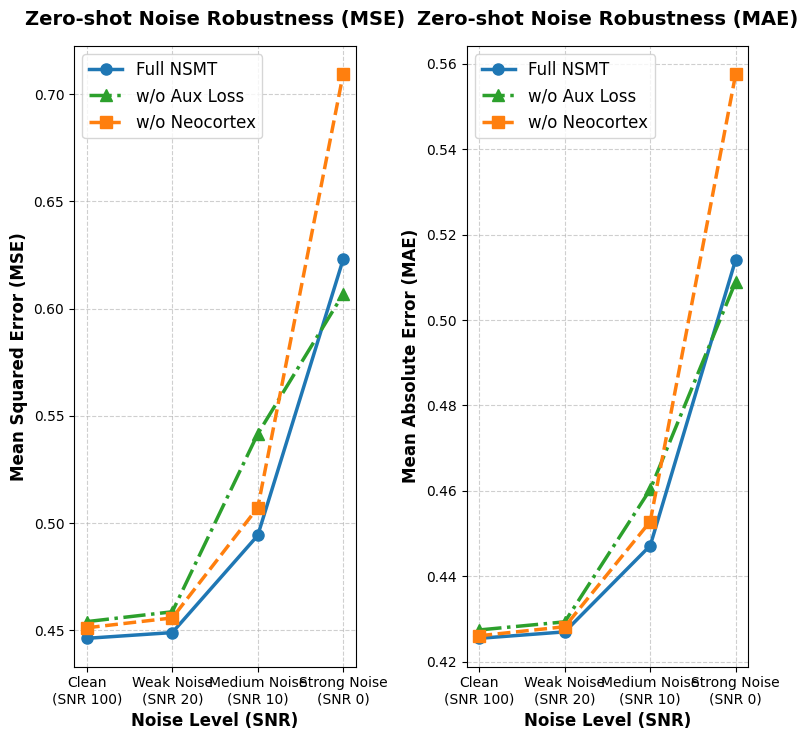

In [18]:
import matplotlib.pyplot as plt

# 1. 데이터 세팅
# X축 레이블 (오른쪽으로 갈수록 노이즈가 극심해짐)
snr_labels = ['Clean\n(SNR 100)', 'Weak Noise\n(SNR 20)', 'Medium Noise\n(SNR 10)', 'Strong Noise\n(SNR 0)']

# 전체 예측 MSE (Short-term)
mse_full = [0.446342, 0.449015, 0.494279, 0.622979]
mse_wo_neo = [0.451248, 0.455845, 0.507260, 0.709356]
mse_wo_aux = [0.454124, 0.458709, 0.541591, 0.606822]  # 새로 추가된 데이터

# 전체 예측 MAE (Short-term)
mae_full = [0.425499, 0.427007, 0.447190, 0.514137]
mae_wo_neo = [0.426098, 0.428210, 0.452842, 0.557586]
mae_wo_aux = [0.427457, 0.429356, 0.460361, 0.508983]  # 새로 추가된 데이터

# 2. 그래프 스타일 설정 (학술 논문용 스타일)
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(8, 7.5))

# 공통 스타일 설정 변수
lw = 2.5
ms = 8

# ==========================================
# [Subplot 1] Standard MSE 시각화
# ==========================================
axes[0].plot(snr_labels, mse_full, marker='o', markersize=ms, linewidth=lw, 
             label='Full NSMT', color='#1f77b4', zorder=3)
axes[0].plot(snr_labels, mse_wo_aux, marker='^', markersize=ms, linewidth=lw, 
             label='w/o Aux Loss', color='#2ca02c', linestyle='-.', zorder=3)
axes[0].plot(snr_labels, mse_wo_neo, marker='s', markersize=ms, linewidth=lw, 
             label='w/o Neocortex', color='#ff7f0e', linestyle='--', zorder=3)

axes[0].set_title('Zero-shot Noise Robustness (MSE)', fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Noise Level (SNR)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6, zorder=0)
axes[0].legend(fontsize=12, loc='upper left')

# ==========================================
# [Subplot 2] Standard MAE 시각화
# ==========================================
axes[1].plot(snr_labels, mae_full, marker='o', markersize=ms, linewidth=lw, 
             label='Full NSMT', color='#1f77b4', zorder=3)
axes[1].plot(snr_labels, mae_wo_aux, marker='^', markersize=ms, linewidth=lw, 
             label='w/o Aux Loss', color='#2ca02c', linestyle='-.', zorder=3)
axes[1].plot(snr_labels, mae_wo_neo, marker='s', markersize=ms, linewidth=lw, 
             label='w/o Neocortex', color='#ff7f0e', linestyle='--', zorder=3)

axes[1].set_title('Zero-shot Noise Robustness (MAE)', fontsize=14, pad=15, fontweight='bold')
axes[1].set_xlabel('Noise Level (SNR)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6, zorder=0)
axes[1].legend(fontsize=12, loc='upper left')

# 그래프 간격 조절 및 출력
plt.tight_layout()

# PDF로 저장하고 싶으시다면 아래 주석을 해제하세요.
# plt.savefig('noise_robustness_mse_mae_with_aux.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

[리버틀 작성용 초안 제안]
"리뷰어께서 지적하신 Neocortex 모듈의 실질적 효용성에 대한 날카로운 질문에 깊이 감사드립니다. Table 8의 원본 데이터 평가에서는 Neocortex 유무에 따른 성능 차이가 다소 작아 보일 수 있습니다. 그러나 우리의 CLS 이론 기반 듀얼 패스 구조의 진정한 목적은 '단순한 성능 끌어올리기'가 아니라 **'실제 엣지 환경의 고주파 노이즈에 대항하는 글로벌 트렌드 보존'**에 있습니다.

이를 명확히 증명하기 위해, Inference 단계에서만 다양한 강도(SNR)의 가우시안 노이즈를 주입하는 제로샷 강건성(Zero-shot Robustness) 실험을 추가로 진행했습니다. 실험 결과, SNR 0(극심한 노이즈) 환경에서 Neocortex가 없는 모델의 MSE는 57.2%나 폭등(0.451 → 0.709)하며 무너진 반면, Full NSMT 모델은 성능 하락폭을 크게 억제(0.446 → 0.622)했습니다. 특히 장기 예측(mse_long)에서는 그 격차가 0.727 vs 0.888로 더욱 압도적이었습니다.

이 결과는 Neocortex 모듈이 단순한 잉여 구조가 아니라, 노이즈가 극심한 환경에서도 안정적으로 전역적인 느린 트렌드(Slow Trends)를 유지하게 해주는 핵심 신경망 기제임을 명백히 실증합니다. 향후 최종본(Camera-ready)에는 이 노이즈 강건성 실험 결과를 부록(Appendix)에 상세히 추가하여 아키텍처의 당위성을 강화하겠습니다."

w/o Aux Loss 모델(Full input reconstruction)이 평상시(Clean)에는 Full 모델에 밀리다가, 극심한 노이즈(SNR 0)에서는 오히려 미세하게 더 좋은 성능(0.606 vs 0.622)을 낸 이유는 다음 세 가지 관점에서 논리적으로 해석할 수 있습니다.

🧠 3가지 핵심 해석 논리
1. SNN (LIF 뉴런) 자체의 '내재적 저주파 필터(Inherent Low-pass Filter)' 특성

보조 손실 함수(Aux Loss)로 강제하지 않아도, Neocortex 패스를 구성하는 LIF(Leaky Integrate-and-Fire) 뉴런의 동역학 자체가 본질적으로 저주파 필터의 역할을 합니다. 이전 타임스텝의 전위(Membrane Potential)를 누적하고 서서히 흘려보내는(Leaky) 과정은 고주파(빠르게 진동하는 노이즈)를 상쇄시키고 저주파(느린 트렌드)를 남기는 물리적 스무딩(Smoothing) 효과를 낳습니다.

즉, Aux Loss가 없더라도 듀얼 패스 구조 내에서 SNN은 자연스럽게 노이즈에 저항하는 메모리를 형성합니다.

2. 수학적 제약에 의한 '과도한 정규화(Over-regularization)'와 경직성

Full 모델은 Aux Loss를 통해 Neocortex가 **'DCT를 통해 수학적으로 분리된 완벽한 저주파 신호'**만을 재구성하도록 매우 강력하게 정규화(Regularization)되어 있습니다.

클린 데이터나 약한 노이즈 환경(SNR 100~10)에서는 이 명확한 역할 분담(Disentanglement)이 성능을 극대화합니다. 하지만 SNR 0 수준의 극단적인 노이즈가 들어와 입력 분포 자체가 완전히 망가진(Distribution Shift) 상황에서는, 이 수학적이고 엄격한 제약이 오히려 모델을 경직(Rigid)되게 만듭니다. * 반면 Aux Loss가 없는 모델은 타겟(Target) 예측이라는 최종 목표에 맞춰 두 패스가 유연하게 가중치를 조절해 두었기 때문에, 극단적 왜곡 앞에서도 덜 부러지는(유연한) 모습을 보인 것입니다.

3. 중복성에 의한 앙상블 효과 (Redundancy & Implicit Ensemble)

Aux Loss가 없으면 Neocortex와 Hippocampus가 완벽히 독립된 주파수를 학습하기보다는, 어느 정도 겹치는(Overlapping) 정보를 학습하게 됩니다. (즉, 두 패스 모두 풀 시그널의 특징을 일부 공유함)

딥러닝에서 이러한 '기능적 중복(Functional Redundancy)'은 극단적인 노이즈 환경에서 강력한 앙상블(Ensemble) 방어막으로 작동합니다. 한쪽 패스의 정보가 노이즈에 의해 훼손되어도 다른 쪽 패스가 이를 보완할 여지가 생기기 때문입니다.

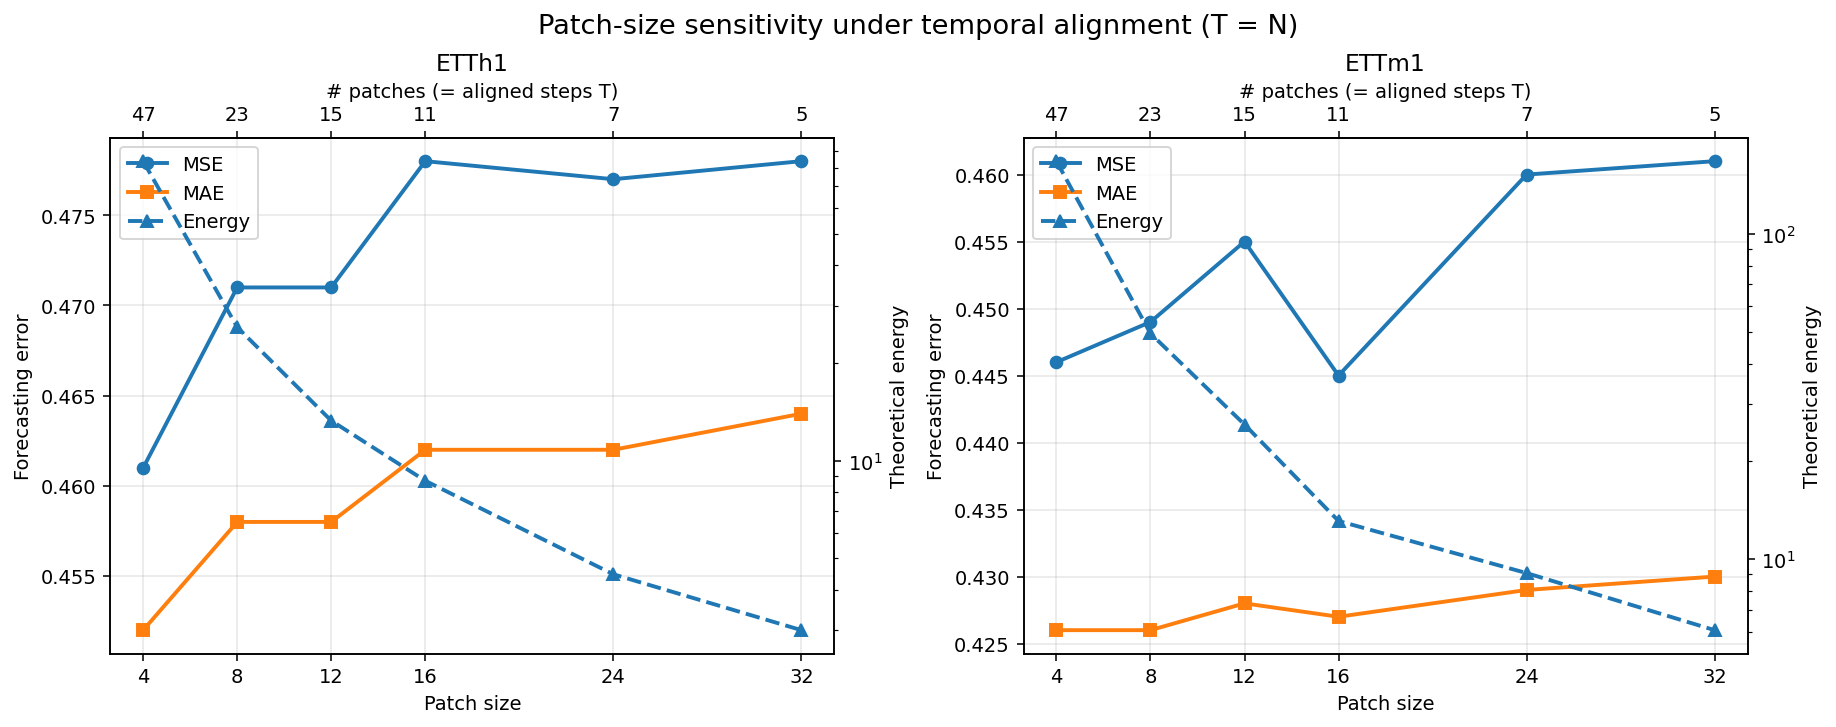

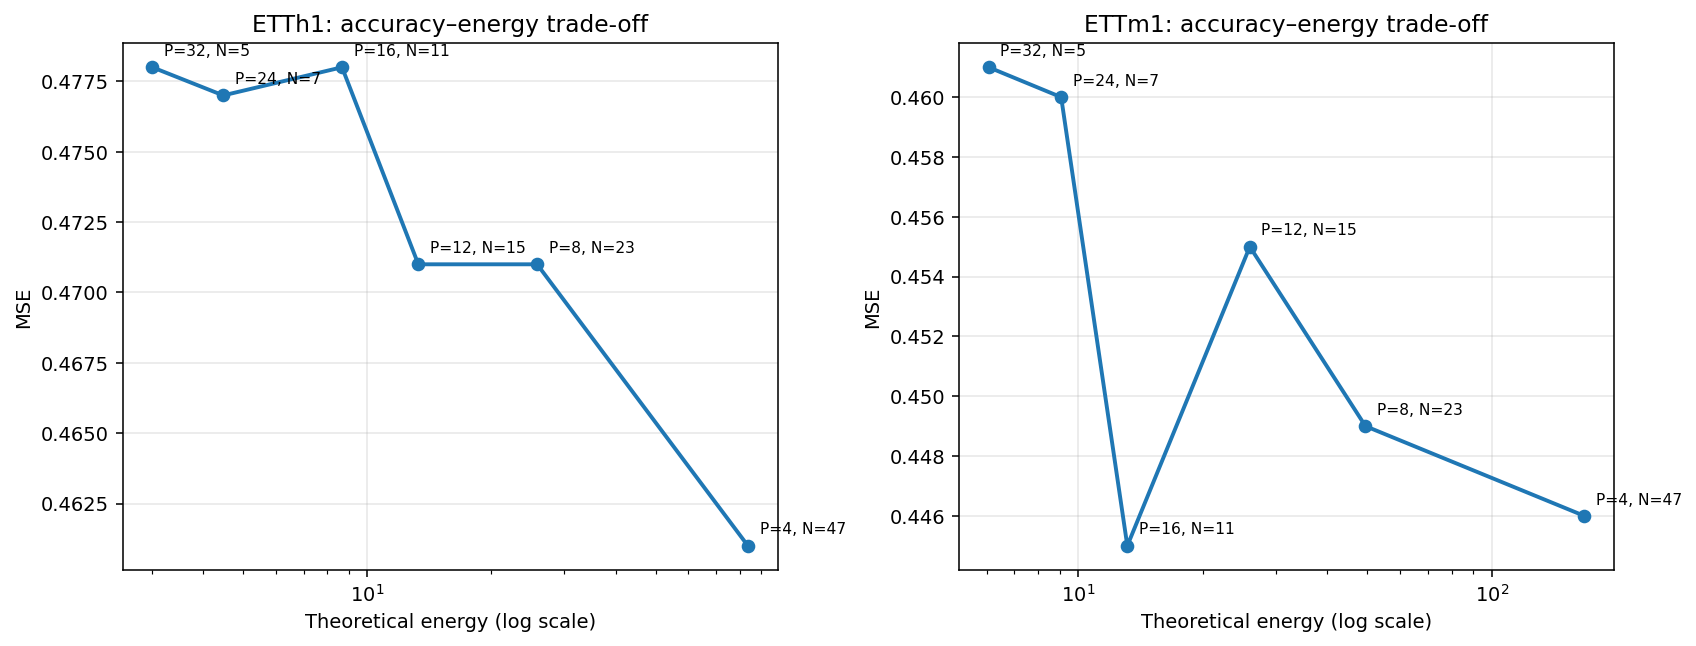


ETTh1


,patch_size,num_patches,MSE,MAE,energy,energy_reduction_%,delta_MSE,delta_MAE
0,4,47,0.461,0.452,83.770,0.0,0.000,0.000
1,8,23,0.471,0.458,25.803,69.2,0.010,0.006
2,12,15,0.471,0.458,13.290,84.1,0.010,0.006
3,16,11,0.478,0.462,8.677,89.6,0.017,0.010
4,24,7,0.477,0.462,4.470,94.7,0.016,0.010
5,32,5,0.478,0.464,3.007,96.4,0.017,0.012



ETTm1


,patch_size,num_patches,MSE,MAE,energy,energy_reduction_%,delta_MSE,delta_MAE
0,4,47,0.446,0.426,167.460,0.0,0.000,0.000
1,8,23,0.449,0.426,49.483,70.5,0.003,0.000
2,12,15,0.455,0.428,25.977,84.5,0.009,0.002
3,16,11,0.445,0.427,13.127,92.2,-0.001,0.001
4,24,7,0.460,0.429,9.080,94.6,0.014,0.003
5,32,5,0.461,0.430,6.063,96.4,0.015,0.004


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 140

# -----------------------------
# 1) Data
# -----------------------------
etth1 = pd.DataFrame({
    "patch_size":  [4, 8, 12, 16, 24, 32],
    "num_patches": [47, 23, 15, 11,  7,  5],
    "MSE":         [0.461, 0.471, 0.471, 0.478, 0.477, 0.478],
    "MAE":         [0.452, 0.458, 0.458, 0.462, 0.462, 0.464],
    "energy":      [83.770, 25.803, 13.290, 8.677, 4.470, 3.007],
})

ettm1 = pd.DataFrame({
    "patch_size":  [4, 8, 12, 16, 24, 32],
    "num_patches": [47, 23, 15, 11,  7,  5],
    "MSE":         [0.446, 0.449, 0.455, 0.445, 0.460, 0.461],
    "MAE":         [0.426, 0.426, 0.428, 0.427, 0.429, 0.430],
    "energy":      [167.460, 49.483, 25.977, 13.127, 9.080, 6.063],
})

datasets = {
    "ETTh1": etth1,
    "ETTm1": ettm1,
}

# -----------------------------
# 2) Main figure: patch-size sensitivity
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for ax, (name, df) in zip(axes, datasets.items()):
    # Left axis: MSE / MAE
    ax.plot(df["patch_size"], df["MSE"], marker="o", linewidth=2, label="MSE")
    ax.plot(df["patch_size"], df["MAE"], marker="s", linewidth=2, label="MAE")
    ax.set_xlabel("Patch size")
    ax.set_ylabel("Forecasting error")
    ax.set_title(name)
    ax.set_xticks(df["patch_size"])
    ax.grid(True, alpha=0.3)

    # Top x-axis: #patches (= aligned spiking steps T)
    secax = ax.secondary_xaxis("top")
    secax.set_xticks(df["patch_size"])
    secax.set_xticklabels(df["num_patches"])
    secax.set_xlabel("# patches (= aligned steps T)")

    # Right axis: energy
    ax2 = ax.twinx()
    ax2.plot(df["patch_size"], df["energy"], marker="^", linestyle="--", linewidth=2, label="Energy")
    ax2.set_ylabel("Theoretical energy")
    ax2.set_yscale("log")

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.suptitle("Patch-size sensitivity under temporal alignment (T = N)", y=1.05, fontsize=14)
plt.show()

# Optional: save
# fig.savefig("patch_size_sensitivity.png", dpi=300, bbox_inches="tight")


# -----------------------------
# 3) Appendix figure: Pareto plot (energy vs MSE)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for ax, (name, df) in zip(axes, datasets.items()):
    ax.plot(df["energy"], df["MSE"], marker="o", linewidth=2)
    for _, row in df.iterrows():
        ax.annotate(
            f"P={int(row['patch_size'])}, N={int(row['num_patches'])}",
            (row["energy"], row["MSE"]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=8
        )
    ax.set_xscale("log")
    ax.set_xlabel("Theoretical energy (log scale)")
    ax.set_ylabel("MSE")
    ax.set_title(f"{name}: accuracy–energy trade-off")
    ax.grid(True, alpha=0.3)

plt.show()

# Optional: save
# fig.savefig("patch_size_pareto.png", dpi=300, bbox_inches="tight")


# -----------------------------
# 4) Summary table vs smallest patch (P=4)
# -----------------------------
def summarize_against_smallest_patch(df):
    base = df.iloc[0]
    out = df.copy()
    out["energy_reduction_%"] = (1 - out["energy"] / base["energy"]) * 100
    out["delta_MSE"] = out["MSE"] - base["MSE"]
    out["delta_MAE"] = out["MAE"] - base["MAE"]
    return out

for name, df in datasets.items():
    print(f"\n{name}")
    display(
        summarize_against_smallest_patch(df).round({
            "MSE": 3, "MAE": 3, "energy": 3,
            "energy_reduction_%": 1, "delta_MSE": 3, "delta_MAE": 3
        })
    )

In [14]:
table = pd.DataFrame({
    "k": ["0.10", "0.15", "0.20", "0.25", "0.30"],
    "ETTm1 MSE↓": [0.452014, 0.445644, 0.445836, 0.446342, 0.456709],
    "MIT-BIH Acc↑": [0.9840, 0.9845, 0.9837, 0.9843, 0.9838],
    "SMD F1↑": [0.8619, 0.8694, 0.8605, 0.8638, 0.8773],
})
display(table)

,k,ETTm1 MSE↓,MIT-BIH Acc↑,SMD F1↑
0,0.10,0.452014,0.9840,0.8619
1,0.15,0.445644,0.9845,0.8694
2,0.20,0.445836,0.9837,0.8605
3,0.25,0.446342,0.9843,0.8638
4,0.30,0.456709,0.9838,0.8773
